# Computational Bioengineering
<hr>

## About this course

Goal of this course is to provide you with means to understand, analyze, and design basic genetic circuits
in cells.
In chapter 1 we start with basic principles of genetic control and discuss:
- cell principles
- circuit principles
- mathematical models to describe genetic circuits
- steady state and dynamic behavior
- separation of time scales
- regulation principles
- activation & repression
- their implications for the design of new circuits



## Coding setup

We will stick to Python 3 code that can be run stand-alone at your computer whenever possible.
When running the code locally on your computer, we suggest to use a virtual environment.
We will install several libraries and a virtual environment helps to not interfere with the system's Python libraries.

For [venv](https://docs.python.org/3/library/venv.html) this is done by running this in the directory that will be used for the lecture:
```sh
python -m venv venv
. ./venv/bin/activate
```

Next let's load some libraries we will need for the course.

In [49]:
# in case you need to install a library run a command like:
# %pip install numpy
# %pip install matplotlib
# %pip install mobspy

# imports
import numpy as np
import matplotlib.pyplot as plt

# configure notebook figures
# remove it in case you run it as stand-alone code
%matplotlib inline

## Introduction into Cells

A cell is a **computing device**: it senses molecular inputs, processes them through a network of biochemical reactions, and produces outputs that determine its behavior: growth, motion, gene expression, division.
This computation has been running, and refined by natural selection, for roughly four billion years.

<figure style="width: 30%; margin: auto; padding: 20px; background-color:white;">
  <img src="figs/life_timeline_wiki.png" alt="Timeline of life on Earth">
  <figcaption><b>Fig:</b> Timeline of life on Earth (from <a href="https://en.wikipedia.org/wiki/Timeline_of_life">Wikipedia</a>)</figcaption>
</figure>

Cells span a wide range of scales: a bacterium such as _E. coli_ occupies about $1\,\mu\text{m}^3 = 1\,\text{fL}$ ([bionumbers](https://bionumbers.hms.harvard.edu/bionumber.aspx?id=100004)), a microalga such as _Chlamydomonas reinhardtii_ roughly $270\,\mu\text{m}^3$ ([bionumber](https://bionumbers.hms.harvard.edu/bionumber.aspx?s=n&v=2&id=110530)), and a typical human cell roughly $500$–$4{,}000\,\mu\text{m}^3$ ([bionumbers](https://book.bionumbers.org/how-big-is-a-human-cell/)). Within each, thousands of molecular species interact through reactions that sense, integrate, and relay signals.

The figure below compares these volumes under the simplifying assumption of cells being balls.


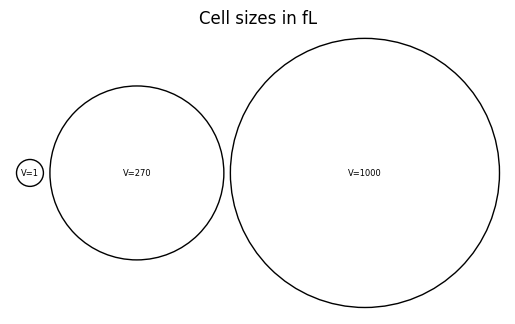

In [50]:
volumes = [1, 270, 1000]
radii = [(3*v/(4*np.pi))**(1/3) for v in volumes]

gap = 0.3
x = [0]
for i in range(1, len(radii)):
    x.append(x[-1] + radii[i-1] + radii[i] + gap)

fig, ax = plt.subplots()

for xi, r, v in zip(x, radii, volumes):
    ax.add_patch(plt.Circle((xi, 0), r, fill=False))
    ax.text(xi, 0, f"V={v}", ha="center", va="center", fontsize=6)

plt.title("Cell sizes in fL")

ax.set_aspect("equal")
ax.set_xlim(x[0] - radii[0] - gap, x[-1] + radii[-1] + gap)
ax.set_ylim(-max(radii) - gap, max(radii) + gap)
ax.axis("off")

plt.show()

Cells have different means to acquire inputs, perform computations, and generate outputs.
These include biochemical mechanisms to:
- **sense** their environment, including nutrient gradients, toxins, and signaling molecules
- **process** the stimuli through cascading networks of proteins, signaling molecules, metabolites, and nucleic acids
- **act** by altering growth rate, secreting molecules, or moving toward or away from a signal

The computational substrate is chemistry rather than silicon, and the relevant timescales are set by molecular collision rates.
Yet the problems solved, from reliable signal detection under molecular noise to robust decision-making with imprecise components and distributed coordination across cell populations, remain ones that challenge our best engineered systems.

Understanding how cells compute, and learning to engineer that computation, is what this course is about.

### Models
To describe (aspects of) a cell's behavior models on different levels of abstraction have been used. During the course we will discuss some of these. An example is Chemical Reaction Networks (CRNs) that describe the evolution of species in a cell via reactions that occur among the species.
Reactions modify, generate, and consume other species.
While such a (chemically inspired) model may seem mostly relevant at a molecular level, we will see that one can also use it at more abstract levels. A core difference there is that we often drop the assumption that mass is preserved in the reactions.
More on this later in the course.

### A model organism: the bacterium _Escherichia coli_ (_E. coli_)
While many of the concepts covered in the course are general to a wide class of cells, we will
often refer to [_E. coli_](https://en.wikipedia.org/wiki/Escherichia_coli) as an example.
_E. coli_ is a gram negative bacterium. It has an inner and outer membrane.

<figure style="width: 700px; margin: auto; padding: 20px; background-color:white;">
  <img src="https://phil.cdc.gov/PHIL_Images/10071/10071_lores.jpg" alt="E.coli">
    <figcaption><b>Fig:</b> <em>E.coli</em> (from CDC, https://phil.cdc.gov)</figcaption>
</figure>

Bacteria belong to the prokaryotes, which is Greek for not "before kernel"; they do not possess of a nucleus such as mammalian cells of humans.

The shape of an is _E. coli_ approximately cylindrical with round caps (rod shaped) with a radius of $0.5\mu$ and length of $2\mu m$. Their volume of about $1 \mu m^3$, or equivalently, $10^{-15} L = 1fL$.
_E. coli_ cultures [grow by cell division](https://www.youtube.com/watch?v=_5bGPa-QXV4) with a rate depending on several factors like strain, temperature, and available nutrients in the growth medium. During fast growth cells duplicate about every 20 min.

Below is a schematic of its membranes from the inside of the cell (cytoplasm, bottom in the figure) to the outside (top in the figure).

<figure style="width: 100%; margin: auto; padding: 20px;">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/8/8b/Gram_negative_cell_wall.svg/1920px-Gram_negative_cell_wall.svg.png" alt="E.coli mombranes">
    <figcaption><b>Fig:</b> <em>E.coli</em> (from wikimedia, https://en.wikipedia.org/wiki/Gram-negative_bacteria)</figcaption>
</figure>

Recently microscopy has made significant advances in capturing high-resolution images of parts of cells. One such image you can find in [Matias, Valério RF, et al., J. of Bacteriology, 2020](https://journals.asm.org/doi/10.1128/JB.185.20.6112-6118.2003#pill-references) Fig.4. of the paper where membranes are nicely visible.

### Genome

The genome of _E. coli_ is a double stranded circular DNA and varies considerably by strain.
For MG1655 (a K-12 substrain) it is 4,641,652 bp long and can be found in the
[ncbh database](https://www.ncbi.nlm.nih.gov/nuccore/U00096).
It comprises of 4,000 to 5,000 genes.

The figure shows the annotated genomes with currently known genes.

<figure style="width: 100%; margin: auto; padding: 20px;">
  <img src="figs/poster-genome-Escherichia-coli-K-12-substr-MG1655.jpg" alt="E.coli genome">
    <figcaption><b>Fig:</b> <em>E.coli genome</em> (from https://ecocyc.org/genbro/genbro.shtml?orgid=ECOLI&replicon=COLI-K12)</figcaption>
</figure>


### Crowded volume
The cytoplasm of a cell should be imagined as a crowded space in contrast to molecules freely floating around.
To get an impression how densely packed it is, see this
[simulation of the cytoplasm of _E. coli_ during 15ms by McGuffee and Elcock](http://cellimagelibrary.org/images/28234).

### The central dogma

**Central dogma.** The flow of genetic information in a cell was summarized by Francis Crick in 1958. DNA stores the heritable sequence information. The universal flows are:

- **Replication**: DNA $\to$ DNA (genome copied before division)
- **Transcription**: DNA $\to$ RNA (a gene is transcribed into messenger RNA)
- **Translation**: RNA $\to$ protein (mRNA translated into amino acid sequence)

Two additional flows occur in specific organisms but are not happening in all cells:
- **Reverse transcription**: RNA $\to$ DNA (retroviruses such as HIV)
- **RNA replication**: RNA $\to$ RNA (RNA viruses)

<figure style="width: 60%; margin: auto; padding: 20px; background-color:white;">
  <img src="https://upload.wikimedia.org/wikipedia/commons/d/dd/Extended_Central_Dogma_with_Enzymes.jpg" alt="Central dogma of molecular biology">
  <figcaption><b>Fig:</b> Central dogma of molecular biology (from <a href="https://en.wikipedia.org/wiki/Central_dogma_of_molecular_biology">Wikipedia</a>)</figcaption>
</figure>

Sequence information does not flow from protein back to nucleic acid under any known natural conditions.



### DNA

A **nucleotide** is the monomer, the basic building brick, of DNA: a phosphate group, a 2′-deoxyribose sugar, and one of four nitrogenous bases: adenine (A), thymine (T), guanine (G), cytosine (C). A and G are purines (two-ring); T and C are pyrimidines (one-ring).

DNA is a **double helix** of two antiparallel polynucleotide strands (Watson and Crick, 1953). The strands are held together by Watson-Crick base pairing: A pairs with T via two hydrogen bonds, G pairs with C via three and thus binds stronger. The higher the G-C content in a DNA segment, the more thermally stable the duplex.

<figure style="width: 60%; margin: auto; padding: 20px; background-color:white;">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/4/4c/DNA_Structure%2BKey%2BLabelled.pn_NoBB.png/960px-DNA_Structure%2BKey%2BLabelled.pn_NoBB.png" alt="DNA double helix structure">
  <figcaption><b>Fig:</b> DNA double helix with labeled structural features (from <a href="https://en.wikipedia.org/wiki/DNA">Wikipedia</a>)</figcaption>
</figure>

<div style="display:flex; justify-content:center; gap:30px; margin:20px 0;">
  <figure style="width:35%; background-color:white; padding:10px; text-align:center;">
    <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/d/db/Base_pair_AT.svg/1920px-Base_pair_AT.svg.png" alt="A-T base pair" style="width:100%;">
    <figcaption><b>A–T</b>: 2 hydrogen bonds</figcaption>
  </figure>
  <figure style="width:35%; background-color:white; padding:10px; text-align:center;">
    <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/6/64/Base_pair_GC.svg/1920px-Base_pair_GC.svg.png" alt="G-C base pair" style="width:100%;">
    <figcaption><b>G–C</b>: 3 hydrogen bonds</figcaption>
  </figure>
</div>

**Direction.** Each strand has chemical polarity: the 5′ end carries a free phosphate on the 5′ carbon of the sugar; the 3′ end carries a free hydroxyl on the 3′ carbon. Synthesis and reading of nucleic acids always proceed 5′ to 3′. The two strands of a duplex are antiparallel: one runs 5′ $\to$ 3′ while its complement runs 3′ $\to$ 5′.

**Plus and minus strands.** By convention the (+) strand, also called the sense or coding strand, has the same sequence as the mRNA (with T in place of U). The (−) strand, the antisense or template strand, is its complement and serves as the template for RNA polymerase during transcription. Which strand is (+) depends on the gene: on a circular bacterial chromosome, different genes use different strands as their template.

### RNA

RNA nucleotides differ from DNA in two respects: the sugar is ribose (with a 2′-OH group) rather than deoxyribose, and uracil (U) replaces thymine (T). U base-pairs with A, just as T does.

**Direction.** RNA is synthesized and read 5′ to 3′, the same convention as DNA. During transcription, RNAP moves along the template strand 3′ $\to$ 5′ and builds the transcript 5′ $\to$ 3′.

RNA is typically **single-stranded**, but extensive intramolecular base pairing creates secondary structures (stems, loops, pseudoknots) that are critical for function. The main functional classes in bacteria are:

| Class | Function |
|-------|----------|
| mRNA | carries coding sequence from gene to ribosome |
| tRNA | adaptor molecule linking codon to amino acid |
| rRNA | structural and catalytic core of the ribosome |
| sRNA | small regulatory RNA, often by base-pairing with mRNA |

In eukaryotes, pre-mRNA undergoes further processing (5′ capping, splicing of introns, 3′ polyadenylation) before export from the nucleus. Bacteria lack these steps: the primary transcript is the mature mRNA.


### Transcription

The enzyme responsible for transcription is **RNA polymerase** (RNAP or simply R). In bacteria, the catalytic core (subunit composition α₂ββ′ω) cannot on its own locate where on the chromosome to begin. The **σ (sigma) factor** is a dissociable subunit that associates with the core to form the **holoenzyme** (α₂ββ′ωσ also written as Rσ). The sigma factor recognizes the **promoter**: a pair of conserved sequence motifs at positions −35 and −10 relative to the transcription start site. After binding, and being in the so-called **closed complex**, the holoenzyme unwinds roughly DNA locally by favorable energetic binding conditions to form the **open complex**, allowing the template strand to enter the active site of the holoenzyme.

Transcription then proceeds in three stages:
1. **Initiation**: holoenzyme binds promoter, transitioning from the closed complex to the open complex. It starts transcribing the DNA, but may easily fall off and interrupt during the first few codons.
Sigma dissociates once elongation is underway.

2. **Elongation**: RNAP moves along the template strand (3′ $\to $ 5′), synthesizing mRNA 5′ $\to$ 3′ at roughly
$40-80\;\text{nt}\,\text{s}^{-1}$ in _E. coli_.

3. **Termination**: RNAP stalls at a terminator sequence and releases the mRNA transcript.

_E. coli_ encodes seven sigma factors. The housekeeping factor $\sigma^{70}$ directs transcription of most genes during exponential growth. Alternative sigma factors (e.g., $\sigma^{32}$) redirect RNAP to stress-response genes, giving the cell a simple mechanism for large-scale transcriptional reprogramming. This is a recurring design motif we will encounter throughout the course.

<figure style="width: 70%; margin: auto; padding: 20px; background-color:white;">
  <img src="https://www.sciencefacts.net/wp-content/uploads/2022/08/Transcription-in-Prokaryotes.jpg" alt="Transcription overview">
  <figcaption><b>Fig:</b> From DNA to mRNA: transcription overview (from <a href="https://www.sciencefacts.net/transcription-in-prokaryotes.html">www.sciencefacts.net</a>).</figcaption>
</figure>


### Translation

The mRNA is decoded by the **ribosome**, a large ribonucleoprotein assembly. In bacteria it consists of a 30S small subunit and a 50S large subunit (together: 70S). The small subunit positions itself on the mRNA via the **Shine-Dalgarno sequence**, a purine-rich stretch about 5-10 nt upstream of the start codon (AUG) that base-pairs with the 3′ end of 16S rRNA.

During elongation, **aminoacyl-tRNAs** enter the A-site, each matching the codon by anticodon base-pairing. The large subunit catalyzes peptide bond formation, the ribosome translocates by one codon, and the growing polypeptide is extended at roughly 15-20 amino acids $\text{s}^{-1}$.
Translation ends at a stop codon (UAA, UAG, or UGA), triggering release of the polypeptide.

<figure style="width: 70%; margin: auto; padding: 20px; background-color:white;">
  <img src="https://upload.wikimedia.org/wikipedia/commons/9/91/Prokaryotic_Translation_Initiation.png" alt="Translation mechanism">
  <figcaption><b>Fig:</b> Translation at the ribosome (from <a href="https://upload.wikimedia.org/wikipedia/commons/9/91/Prokaryotic_Translation_Initiation.png">Wikipedia</a>)</figcaption>
</figure>

In bacteria, transcription and translation are **spatially coupled**: ribosomes begin translating the 5′ end of an mRNA while RNAP is still synthesizing the 3′ end. This co-transcriptional translation is absent in eukaryotes, where transcription occurs in the nucleus and mRNA must be exported before cytoplasmic translation can begin.

## Pathways in _E. coli_

Reactions are typically grouped together into pathways, that describe reactions for a certain cell function. 
Examples are the modification of molecules by enzymes along _metabolic pathways_ as well as transcription and translation in _genetic pathways_.
An overview of reactions grouped into pathways is shown in the figure below.
An interactive schematic is available [here by ecocyc](https://ecocyc.org/overviewsWeb/celOv.shtml?orgid=ECOLI) and lists of pathways available, e.g., by [biocyc](https://biocyc.org/ECOLI/class-tree?object=Pathways) and
[kegg](https://www.genome.jp/kegg/pathway.html#cellular).

<figure style="width: 100%; margin: auto; padding: 20px; background-color:white;">
  <img src="figs/ecoli_reactions.png" alt="araA in pathway">
    <figcaption><b>Fig:</b> schematic of <em>E. coli</em> pathways (from ecocyc, https://ecocyc.org/overviewsWeb/celOv.shtml?orgid=ECOLI)</figcaption>
</figure>

Below is an excerpt of reactions from a genetic pathway that includes the transcription of the araA gene.
See [here](https://ecocyc.org/gene?orgid=ECOLI&id=EG10052) for an interactive version.
These reations will play a role later on in the course.

<figure style="width: 100%; margin: auto; padding: 20px; background-color:white;">
  <img src="figs/araA.png" alt="araA in pathway">
  <figcaption><b>Fig:</b> araA gene in pathways (from ecocyc, https://ecocyc.org/gene?orgid=ECOLI&id=EG10052)</figcaption>
</figure>




---
**License & Attribution**: This page is adapted from material by [Michael Elowitz and Justin Bois](https://biocircuits.github.io/) (© 2021–2025), licensed under [CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/).